**1. Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")


**2. Load and Inspect the Dataset**

In [ ]:
# Load the dataset
df = pd.read_csv("/content/1747137684388_diabetes_dataset.csv")

# Basic overview
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())


   Unnamed: 0  Age     Sex Ethnicity   BMI  Waist_Circumference  \
0           0   58  Female     White  35.8                 83.4   
1           1   48    Male     Asian  24.1                 71.4   
2           2   34  Female     Black  25.0                113.8   
3           3   62    Male     Asian  32.7                100.4   
4           4   27  Female     Asian  33.5                110.8   

   Fasting_Blood_Glucose  HbA1c  Blood_Pressure_Systolic  \
0                  123.9   10.9                      152   
1                  183.7   12.8                      103   
2                  142.0   14.5                      179   
3                  167.4    8.8                      176   
4                  146.4    7.1                      122   

   Blood_Pressure_Diastolic  ...  Cholesterol_HDL  Cholesterol_LDL   GGT  \
0                       114  ...             50.2             99.2  37.5   
1                        91  ...             62.0            146.4  88.5   
2       

**3. Data Cleaning and Preprocessing**

In [ ]:
# Fill missing values (example strategy: median for numeric, mode for categorical)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encoding categorical variables
label_encoders = {}
for col in ['Sex', 'Ethnicity', 'Smoking_Status', 'Family_History_of_Diabetes', 'Previous_Gestational_Diabetes']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define target variable (e.g., diabetes risk based on high HbA1c or glucose)
df['Diabetes_Risk'] = np.where((df['HbA1c'] >= 6.5) | (df['Fasting_Blood_Glucose'] >= 126), 1, 0)

# Drop original indicators to avoid leakage
df.drop(['HbA1c', 'Fasting_Blood_Glucose'], axis=1, inplace=True)


4. Exploratory Data Analysis (EDA)

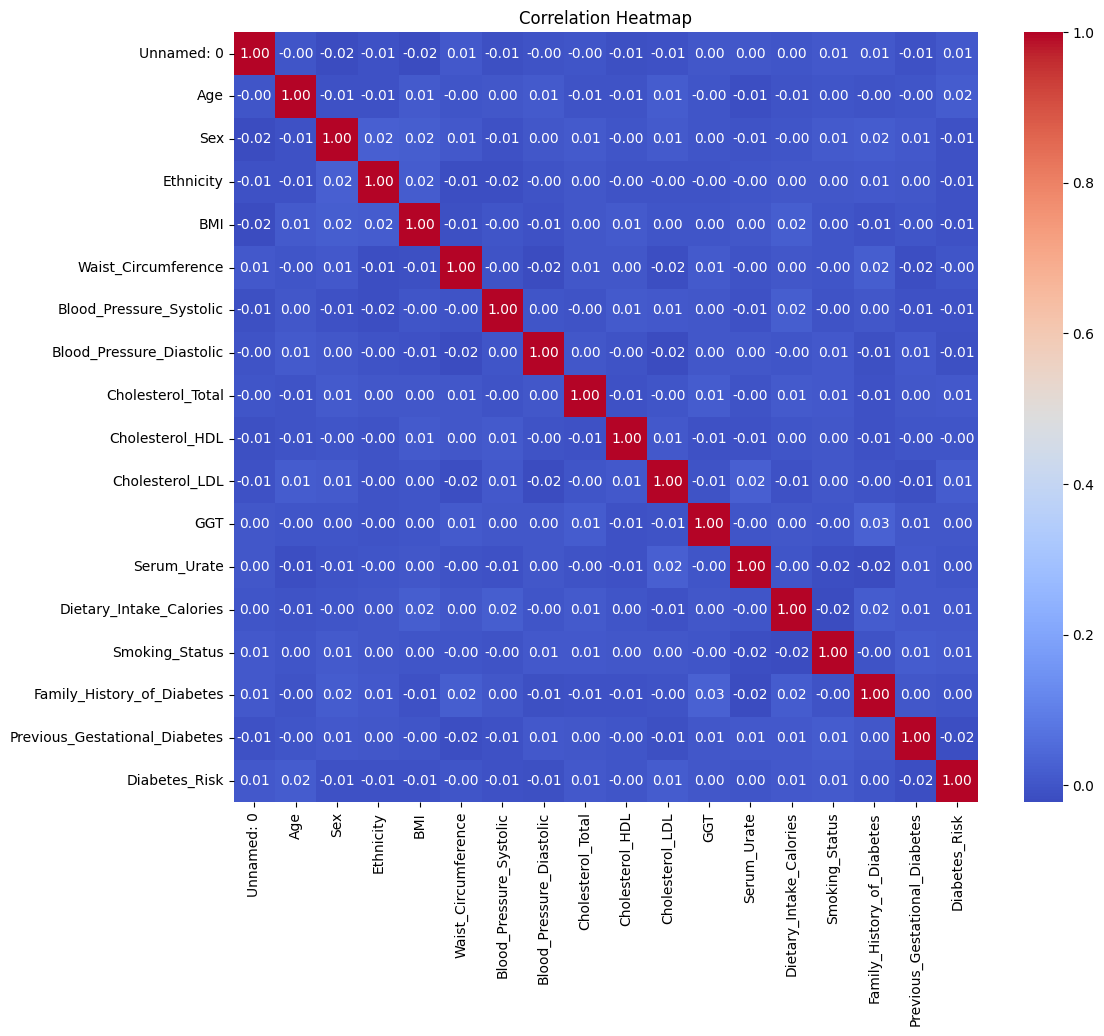

In [ ]:
# Correlation heatmap with numeric data only
plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include=[np.number])  # only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Age Distribution by Diabetes Risk

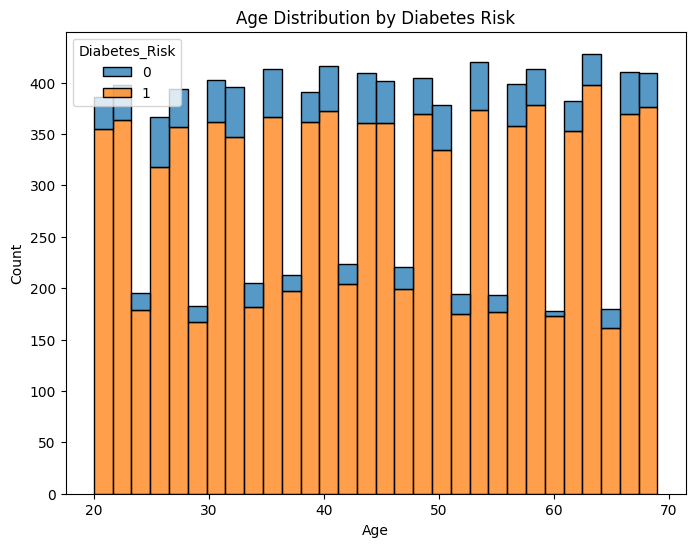

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='Age', hue='Diabetes_Risk', multiple='stack', bins=30)
plt.title("Age Distribution by Diabetes Risk")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


BMI Distribution by Diabetes Risk

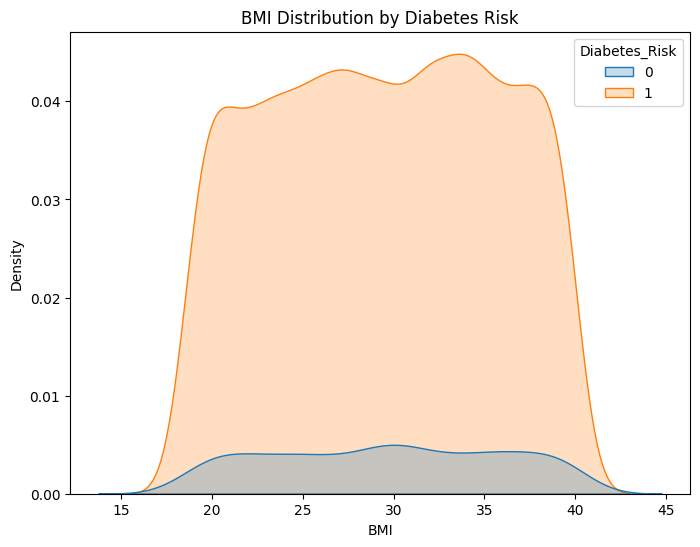

In [ ]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x='BMI', hue='Diabetes_Risk', fill=True)
plt.title("BMI Distribution by Diabetes Risk")
plt.xlabel("BMI")
plt.show()



Boxplot of Waist Circumference by Risk


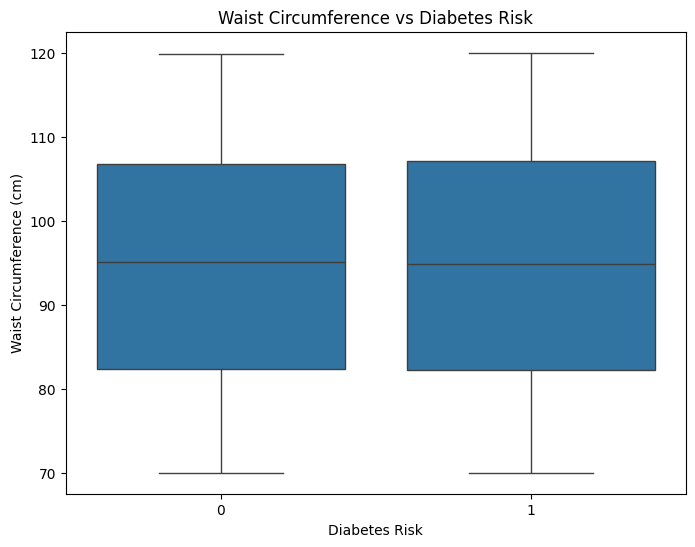

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Diabetes_Risk', y='Waist_Circumference', data=df)
plt.title("Waist Circumference vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Waist Circumference (cm)")
plt.show()


Physical Activity Level vs Diabetes Risk

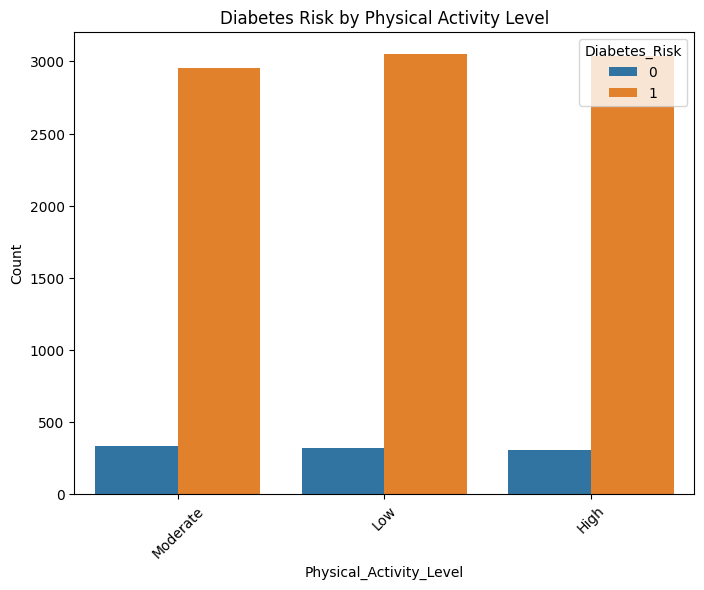

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='Physical_Activity_Level', hue='Diabetes_Risk', data=df)
plt.title("Diabetes Risk by Physical Activity Level")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()


Systolic Blood Pressure by Risk

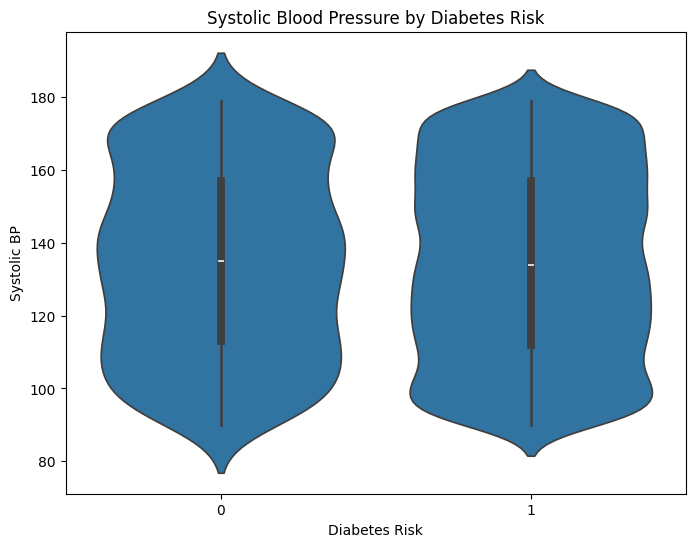

In [ ]:
plt.figure(figsize=(8,6))
sns.violinplot(x='Diabetes_Risk', y='Blood_Pressure_Systolic', data=df)
plt.title("Systolic Blood Pressure by Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Systolic BP")
plt.show()


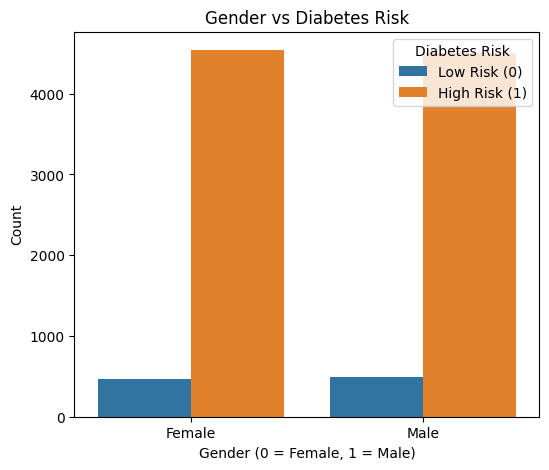

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(x='Sex', hue='Diabetes_Risk', data=df)
plt.title("Gender vs Diabetes Risk")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(title='Diabetes Risk', labels=['Low Risk (0)', 'High Risk (1)'])
plt.show()


BMI Distribution by Gender

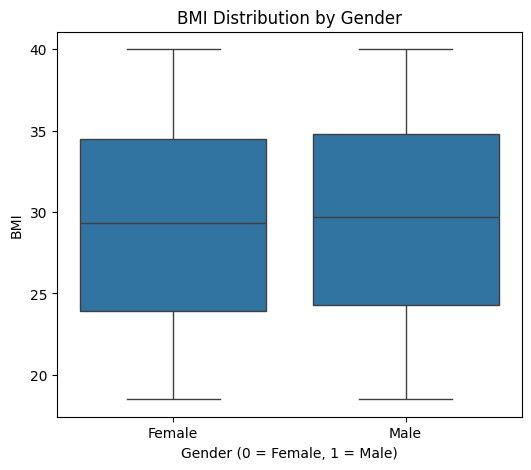

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Sex', y='BMI', data=df)
plt.title("BMI Distribution by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("BMI")
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()


5. Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Make a copy to avoid modifying original dataframe
df_encoded = df.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

# Label encode each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # Save encoder if needed for decoding later

# Separate features and target
X = df_encoded.drop('Diabetes_Risk', axis=1)
y = df_encoded['Diabetes_Risk']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


6. Train-Test Split



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


7. Model Training and Selection

Logistic Regression

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)


Decision Tree

In [ ]:
dtree = DecisionTreeClassifier(max_depth=5)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)


Random Forest

In [ ]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=5)
rfc.fit(X_train, y_train)
y_pred_rf = rfc.predict(X_test)


8. Model Evaluation

----- Logistic Regression -----
Accuracy: 0.9095
Precision: 0.9095
Recall: 1.0
F1 Score: 0.9526053940822204
Confusion Matrix:
 [[   0  181]
 [   0 1819]]


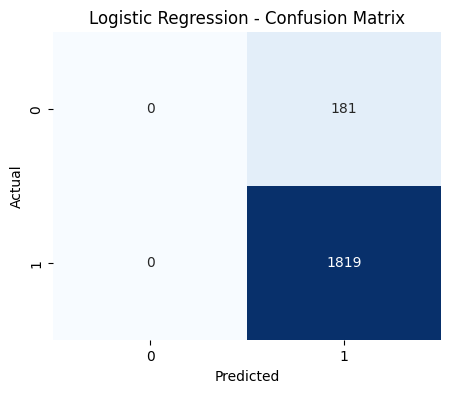

----- Decision Tree -----
Accuracy: 0.9085
Precision: 0.9098196392785571
Recall: 0.9983507421660253
F1 Score: 0.9520314547837484
Confusion Matrix:
 [[   1  180]
 [   3 1816]]


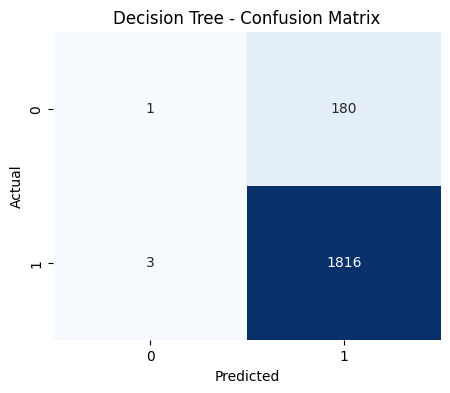

----- Random Forest -----
Accuracy: 0.9095
Precision: 0.9095
Recall: 1.0
F1 Score: 0.9526053940822204
Confusion Matrix:
 [[   0  181]
 [   0 1819]]


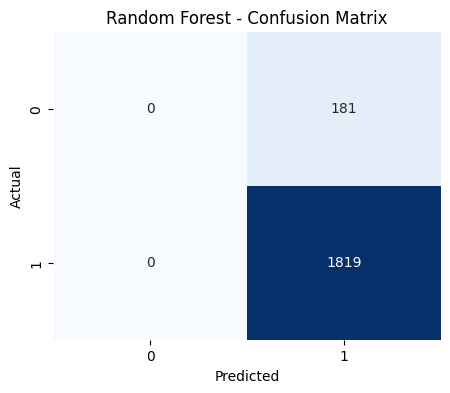

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": y_pred_logreg,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

for model_name, y_pred in models.items():
    print(f"----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    # Confusion matrix - numeric
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # Confusion matrix - heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


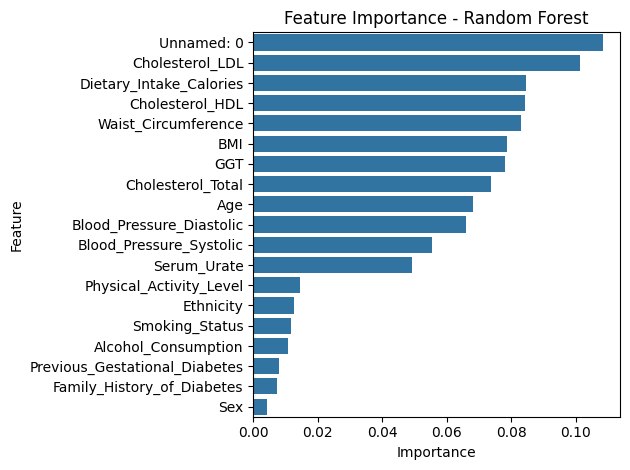

In [ ]:
importances = rfc.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=False, inplace=True)

sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()
